# Imports and constants

In [50]:
import toml
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import scipy.optimize as op

In [51]:
# Simulation data folders
dirpath_sim = "/net/debye/gmennella/randium/sims"
dirpath_sim_square = f"{dirpath_sim}/sims_square"

# Output folders
outdirpath_fig = "/net/debye/gmennella/randium/analysis/analysis_figure"
outdirpath_data = "/net/debye/gmennella/randium/analysis/analysis_data"

# Relax time criterion
overlap_target = .5

# Plot params.
fontsize_label = 15
fontsize_title = 16
fontsize_legend = 12

# Functions

In [52]:
def get_filepath(beta, version, device, dirpath=dirpath_sim_square):

    filepath = f"{dirpath}/runs_{version}/Data/{device}_192x192beta{beta:1.4f}.csv"

    return filepath

In [53]:
def find_relax_time(time_list, overlap_list, target=overlap_target):
    """"
    Find the relaxation time, defined as the time 
    such that the overlap value is equal to target.
    """

    # "Short" dynamics: overlap decreases to target.
    if (np.max(overlap_list) > target 
        and np.min(overlap_list) < target):

        time_idx = np.argmin(np.abs(overlap_list - target))
        relax_time = time_list[time_idx]

        return relax_time

    # "Long" dynamics: overlap decreases outside of
    # time window.
    else:

        return None    

# Long runs - Stretched exponent:

## Data loading

In [54]:
beta_list_long = np.array([
    1.00, 1.30, 
    1.40, 1.45, 1.50, 1.55, 
    1.60, 1.65, 1.70, 1.75,
    1.80
])

data_mat_long = [
    pd.read_csv(get_filepath(beta, version="v3", device="gpu"))
    for beta in beta_list_long
]

time_mat_long = [
    data['time'] for data in data_mat_long
]

overlap_mat_long = [
    data['particle_overlap'] for data in data_mat_long
]

# Build beta values dictionary.
beta_dict_long = {
    beta: idx for idx, beta in enumerate(beta_list_long)
}

print(beta_dict_long)

{np.float64(1.0): 0, np.float64(1.3): 1, np.float64(1.4): 2, np.float64(1.45): 3, np.float64(1.5): 4, np.float64(1.55): 5, np.float64(1.6): 6, np.float64(1.65): 7, np.float64(1.7): 8, np.float64(1.75): 9, np.float64(1.8): 10}


## Plot

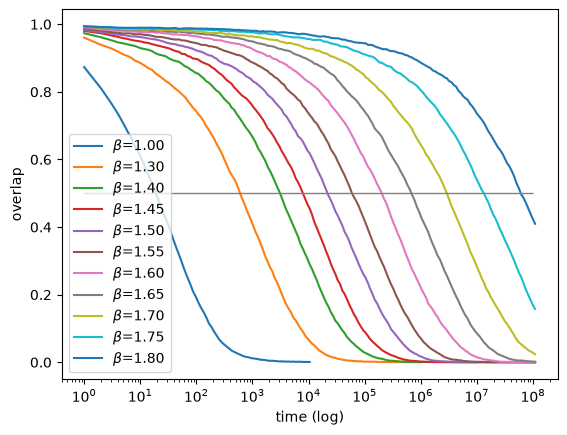

In [55]:
for time_list, overlap_list, beta in zip(
    time_mat_long,
    overlap_mat_long,
    beta_list_long,
    strict=True
):
    plt.plot(time_list, overlap_list, label=f'$\\beta$={beta:.2f}')

plt.hlines(overlap_target, 1., 10**8, colors='gray', linewidth=1)

plt.xscale("log")

plt.xlabel("time (log)")
plt.ylabel("overlap")
plt.legend()

## Analysis - Equilibration time

In [56]:
tau_list_long = np.array([
    find_relax_time(time_list, overlap_list)
    for time_list, overlap_list in zip(time_mat_long, overlap_mat_long)
])

print(beta_list_long)
print(tau_list_long)

[1.   1.3  1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8 ]
[      19      573     3008     7855    22484    58390   201700   696468
  2909530 13369484 61432713]


### Plot - tau vs beta

Text(0.5, 1.0, 'Equilibration time vs $\\beta$ | King')

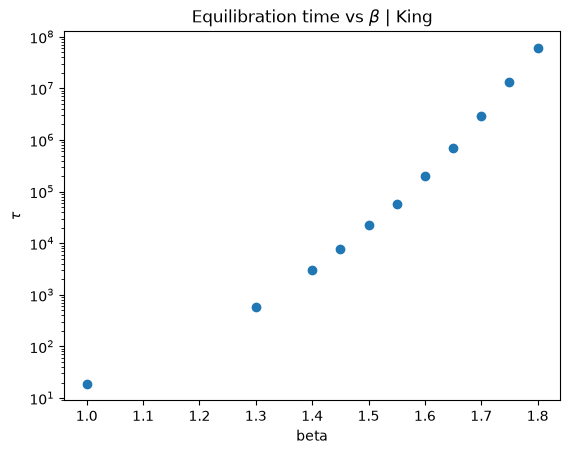

In [57]:
plt.plot(beta_list_long, tau_list_long, 'o')

plt.yscale("log")

plt.xlabel("beta")
plt.ylabel("$\\tau$")
plt.title("Equilibration time vs $\\beta$ | King")

## Plot - Curve collapse

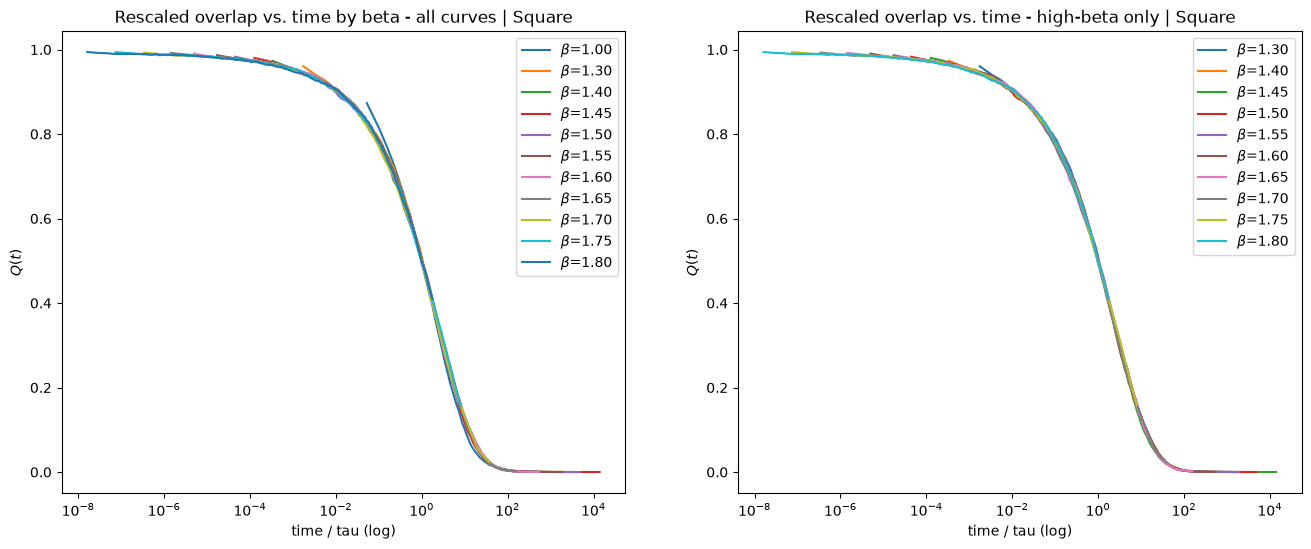

In [58]:
# Plot.
nrows = 1
ncols = 2

fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))

# Plot 1: ALL curves.
plot_start_idx = 0
plot_stop_idx = None

for time_list, overlap_list, tau, beta in zip(
    time_mat_long[plot_start_idx:plot_stop_idx],
    overlap_mat_long[plot_start_idx:plot_stop_idx],
    tau_list_long[plot_start_idx:plot_stop_idx],
    beta_list_long[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        axs[0].plot(time_list / tau, overlap_list, label=f'$\\beta$={beta:.2f}')

# plt.hlines(overlap_target, 1., 10**8, colors='gray', linewidth=1)

axs[0].set_xscale("log")

axs[0].set_xlabel("time / tau (log)")
axs[0].set_ylabel("$Q(t)$")
axs[0].set_title("Rescaled overlap vs. time by beta - all curves | Square")
axs[0].legend()

# Plot 2: Remove low-beta curves.
plot_start_idx = 1
plot_stop_idx = None

for time_list, overlap_list, tau, beta in zip(
    time_mat_long[plot_start_idx:plot_stop_idx],
    overlap_mat_long[plot_start_idx:plot_stop_idx],
    tau_list_long[plot_start_idx:plot_stop_idx],
    beta_list_long[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        axs[1].plot(time_list / tau, overlap_list, label=f'$\\beta$={beta:.2f}')

# plt.hlines(overlap_target, 1., 10**8, colors='gray', linewidth=1)

axs[1].set_xscale("log")

# axs[1].set_xlim(1, 10**2)

axs[1].set_xlabel("time / tau (log)")
axs[1].set_ylabel("$Q(t)$")
axs[1].set_title("Rescaled overlap vs. time - high-beta only | Square")
axs[1].legend()

## Fit - Stretched exponent:

In [59]:
def stretched_exp(t, A, t0, alpha):

    curve = A * np.exp(- np.power(t / t0, alpha))

    return curve

def log_stretched_exp(t, A, t0, alpha):

    curve = - np.power(t / t0, alpha) + np.log(A)

    return curve

### Automatic fitting

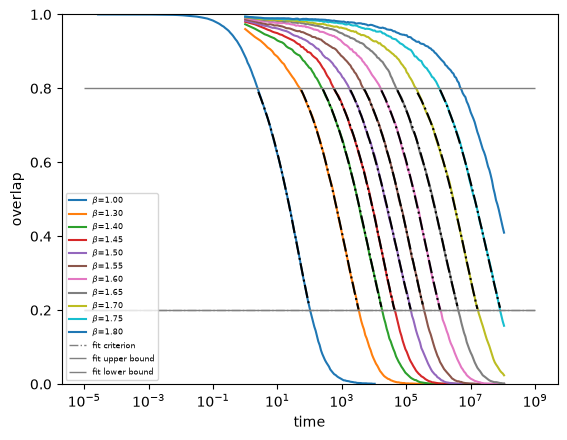

In [60]:
# Select which beta curves to fit.
beta_list = beta_list_long

# Select data folder.
data_dir = "/net/debye/gmennella/randium/sims/sims_square/runs_v3/Data"

# At what time stitch CPU and GPU data.
stitch_time = 10_000
# Criterion to select the curves to analyse.
Q_criterion = 0.2
# Overlap range of values to fit.
Q_min, Q_max = 0.2, 0.8

# Initial guess for fit params.
p0 = [1.0, 0.5, 0.9]

# Storage for fit results.
beta_fit_list = []
A_fit_list = []
t0_fit_list = []
alpha_fit_list = []

# Used to select when to use cpu values.
beta_cpu = 1.1

for idx, beta in enumerate(beta_list):

    fname = f'192x192beta{beta:1.4f}'

    # Load metadata.
    metadata = toml.load(data_dir + f'/cpu_{fname}.toml')
    N = metadata['N']

    # Load CPU data.
    if beta <= beta_cpu:

        cpu_data = pd.read_csv(data_dir + f'/cpu_{fname}.csv')
        cpu_time_list = np.array(cpu_data['time'])
        cpu_overlap_list = np.array(cpu_data['particle_overlap'])

        cpu_Q_list = (cpu_overlap_list - 1 / N) / (1 - 1 / N)

    # Only use GPU data.
    else:
        cpu_time_list = cpu_Q_list = []

    # Load GPU data.
    gpu_data = pd.read_csv(data_dir + f'/gpu_{fname}.csv')
    gpu_time_list = np.array(gpu_data['time'])
    gpu_overlap_list = np.array(gpu_data['particle_overlap'])

    gpu_Q_list = (gpu_overlap_list - 1 / N) / (1 - 1 / N)

    if beta <= beta_cpu:
        gpu_mask = (gpu_time_list > stitch_time)
    else:
        gpu_mask = np.ones_like(gpu_time_list, dtype=bool)
    

    # Stitch data together
    time_list = np.concatenate(
        [cpu_time_list, gpu_time_list[gpu_mask]]
    )
    Q_list = np.concatenate(
        [cpu_Q_list, gpu_Q_list[gpu_mask]]
    )

    # Plot.
    plt.plot(
        time_list, Q_list,
        label=f'$\\beta$={beta:1.2f}',
    )

    # Fit.
    if min(Q_list) < Q_criterion:

        fit_mask = (Q_list > Q_min) & (Q_list < Q_max)
        time_fit_list = time_list[fit_mask]
        Q_fit_list = Q_list[fit_mask]

        popt, pcov = op.curve_fit(
            stretched_exp,
            time_fit_list,
            Q_fit_list,
            p0=p0,
            bounds=(
                [.8, 0., 0.],
                [1.2, np.inf, 1.]
            )
        )

        A, t0, alpha = popt
        beta_fit_list.append(beta)
        A_fit_list.append(A)
        t0_fit_list.append(t0)
        alpha_fit_list.append(alpha)

        # Updated p0 to last popt found.
        p0 = popt

        # Fit plot.
        plt.plot(
            time_fit_list, 
            stretched_exp(
                time_fit_list,
                A=A, t0=t0, alpha=alpha
            ),
            color='black',
            linestyle='-.'
        )


# ===== Plot =====
plt.hlines(
    Q_criterion, xmin=10**(-5), xmax=10**9,
    label='fit criterion',
    colors='gray',
    linestyles='-.',
    linewidth=1
)
plt.hlines(
    Q_max, xmin=10**(-5), xmax=10**9,
    label='fit upper bound',
    colors='gray',
    linewidth=1
)
plt.hlines(
    Q_min, xmin=10**(-5), xmax=10**9,
    label='fit lower bound',
    colors='gray',
    linewidth=1
)

plt.xscale("log")

plt.ylim(0., 1.)

plt.xlabel("time")
plt.ylabel("overlap")
plt.legend(
    fontsize=6,
    loc='lower left',
)

## Plot - Fit results

(0.0, 1.0)

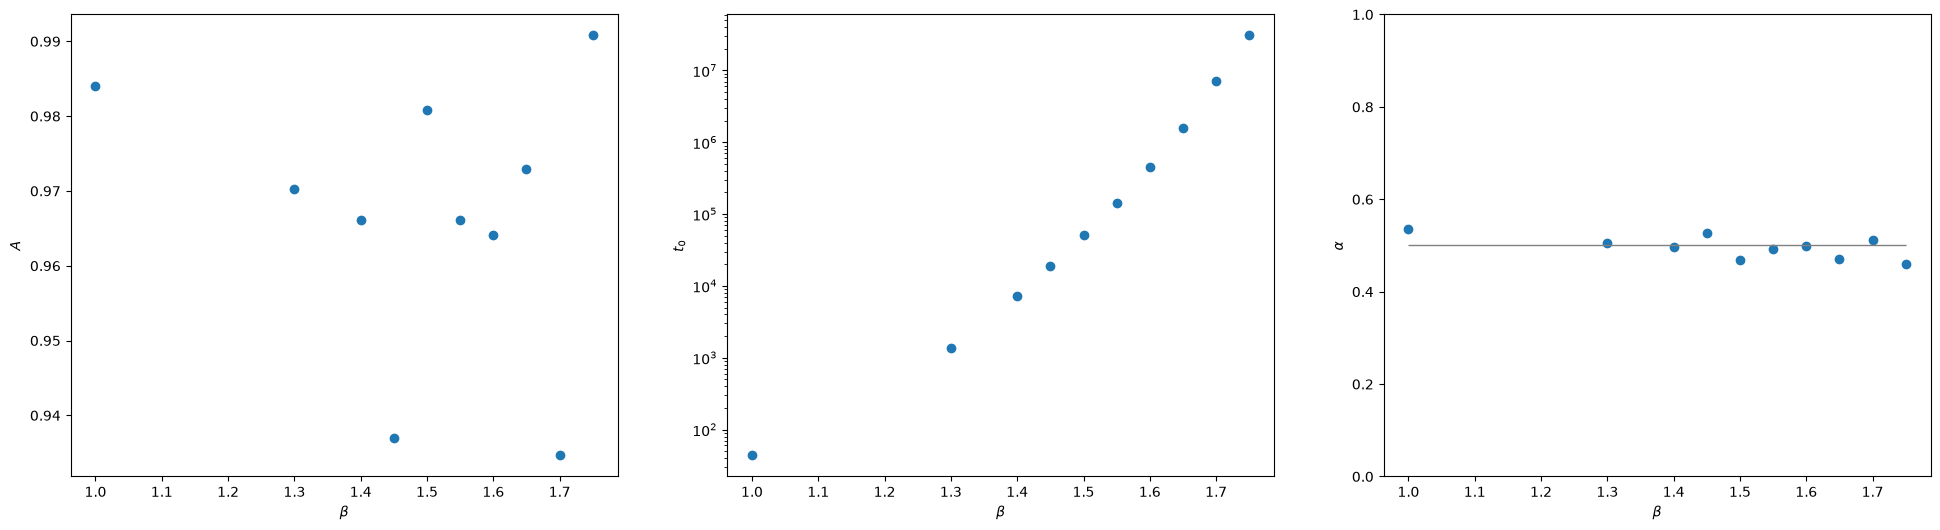

In [61]:
nrows, ncols = 1, 3

fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))

# ===== A plot =====
plot_idx = 0

axs[plot_idx].plot(beta_fit_list, A_fit_list, 'o')
axs[plot_idx].set_xlabel("$\\beta$")
axs[plot_idx].set_ylabel("$A$")

# ===== t0 plot =====
plot_idx = 1

axs[plot_idx].plot(beta_fit_list, t0_fit_list, 'o')
axs[plot_idx].set_yscale("log")
axs[plot_idx].set_xlabel("$\\beta$")
axs[plot_idx].set_ylabel("$t_0$")

# ===== alpha plot =====
plot_idx = 2

axs[plot_idx].plot(beta_fit_list, alpha_fit_list, 'o')
axs[plot_idx].hlines(
    .5, 
    min(beta_fit_list), 
    max(beta_fit_list),
    color='gray',
    linewidth=1
)
axs[plot_idx].set_xlabel("$\\beta$")
axs[plot_idx].set_ylabel("$\\alpha$")
axs[plot_idx].set_ylim(0, 1)

In [97]:
# Save results
filepath_save_fit = f"{outdirpath_data}/square_stretched_exp_fit.dat"

header_save_stretched_fit = (
    "Square lattice - Fit result for overlap vs time.\n"
    "beta | A | t0 | alpha"
)

np.savetxt(
    fname=filepath_save_fit,
    X=np.transpose(
        [beta_fit_list, A_fit_list, t0_fit_list, alpha_fit_list]
    ),
    header=header_save_stretched_fit
)

# Short runs - Equilibration time:

## Data loading

In [63]:
# === Select beta values ===
beta_list_short_cpu = [
    0.0001,
    0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70,
    0.80, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89,
    0.9,
    1.0
]
beta_list_short_gpu = [
    1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40, 1.45,
    1.50, 1.55, 1.575, 
    1.60, 1.65, 1.70, 1.75, 1.80
]

beta_list_short = np.array(beta_list_short_cpu + beta_list_short_gpu)

# === Load csv data ===
data_mat_short_cpu = [
    pd.read_csv(get_filepath(beta, version="v3_short", device="cpu"))
    for beta in beta_list_short_cpu
]
data_mat_short_gpu = [
    pd.read_csv(get_filepath(beta, version="v3_short", device="gpu"))
    for beta in beta_list_short_gpu
]

data_mat_short = data_mat_short_cpu + data_mat_short_gpu

# === Select time and overlap ===
time_mat_short = [
    np.array(data['time']) for data in data_mat_short
]

overlap_mat_short = [
    np.array(data['particle_overlap']) for data in data_mat_short
]

## Plot

Text(0.5, 1.0, 'Overlap vs. time by beta | Square')

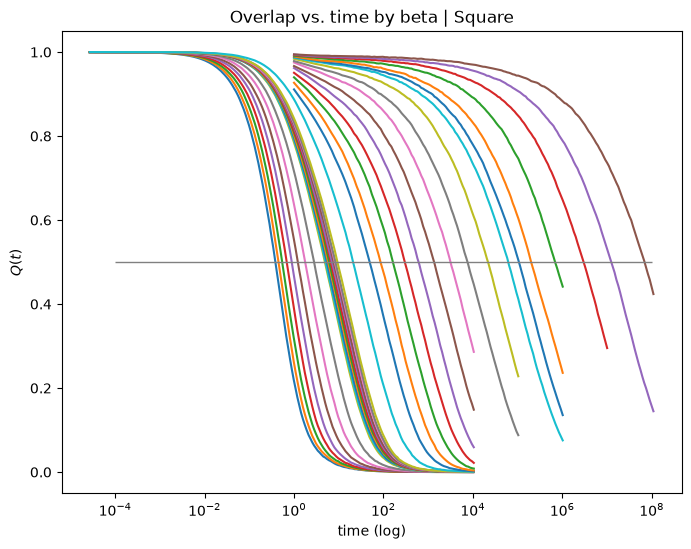

In [64]:
plt.figure(figsize=(8,6))

for time_list, overlap_list, beta in zip(
    time_mat_short,
    overlap_mat_short,
    beta_list_short,
    strict=True
):
    plt.plot(time_list, overlap_list, label=f'$\\beta$={beta:.2f}')

plt.hlines(overlap_target, 10**(-4), 10**8, colors='gray', linewidth=1)

plt.xscale("log")

plt.xlabel("time (log)")
plt.ylabel("$Q(t)$")
plt.title("Overlap vs. time by beta | Square")
# plt.legend()

## Analysis - Relaxation time

In [65]:
tau_list_short = np.array([
    find_relax_time(time_list, overlap_list)
    for time_list, overlap_list in zip(time_mat_short, overlap_mat_short)
], dtype=float)

In [66]:
# Save results
filepath_save_tau = f"{outdirpath_data}/square_tau_vs_beta.dat"

header_save_tau = ("Square lattice - Relaxation time tau "
                   "vs inverse temperature beta. "
                   "Note: include cases where tau is not found.\n"
                   "beta | tau")

np.savetxt(
    fname=filepath_save_tau,
    X=np.transpose([beta_list_short, tau_list_short]),
    header=header_save_tau
)

## Plot - tau vs beta

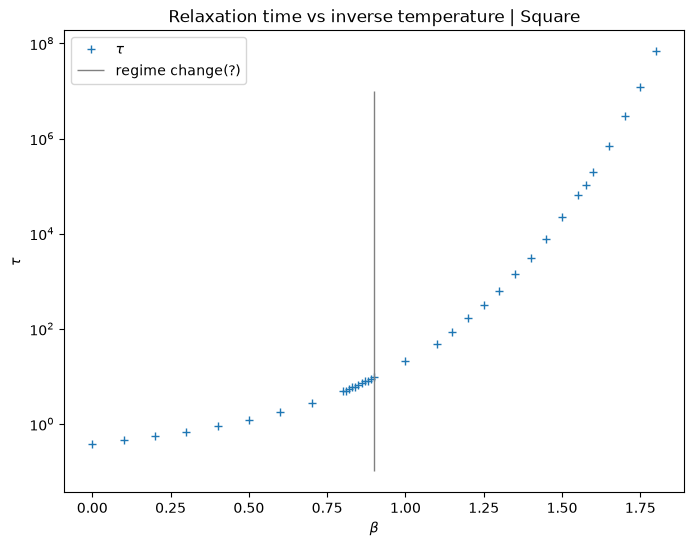

In [67]:
plt.figure(figsize=(8,6))

plt.plot(beta_list_short, tau_list_short, '+', label='$\\tau$')

plt.vlines(
    0.9, 
    ymin=0.1,
    ymax=10**7,
    label='regime change(?)',
    color='gray',
    linewidth=1
)

plt.yscale("log")

plt.xlabel("$\\beta$")
plt.ylabel("$\\tau$")
plt.title("Relaxation time vs inverse temperature | Square")
plt.legend()

## Fit - Relaxation time

In [68]:
def get_parabolic_fit_J_and_stdJ(a, var_a):
    """"
    Get J estimation and standard deviation from
    parabolic fit result.

    J = sqrt(a)
    var[J] = 0.25 / a * var[a]
    std[J] = sqrt(var[J])
    """

    J = np.sqrt(a)
    var_J = .25 / a * var_a
    std_J = np.sqrt(var_J)

    return J, std_J


def get_parabolic_fit_beta_q_and_std_beta_q(a, b, var_a, var_b, cov_ab):
    """"
    Get beta_q estimation and standard deviation from
    parabolic fit result.

    beta_q = -b / (2 * a)
    var[beta_q] = (0.5 * b / a**2)**2 * var[a] +
                    (0.5 / a)**2 * var[b] +
                    2 * (-0.25 * b / a**3) * cov[a,b]
    std[beta_q] = sqrt(var[beta_q])
    """

    beta_q = -b / (2 * a)
    dbeta_da = .5 * b / a**2
    dbeta_db = - .5 / a
    var_beta_q = (
        dbeta_da**2 * var_a + dbeta_db**2 * var_b
        + 2 * dbeta_da * dbeta_db * cov_ab
    )
    std_beta_q = np.sqrt(var_beta_q)

    return beta_q, std_beta_q


def get_parabolic_fit_log_tau_q_and_std_log_tau_q(
    a, b, c,
    var_a, var_b, var_c,
    cov_ab, cov_bc, cov_ac
):
    """"
    Get log(tau_q) estimation and standard deviation from
    parabolic fit result.

    log(tau_q) = c -b**2 / (4 * a)
    var[log(tau_q)] = ((0.5 * b / a**2)**2)**2 * var[a] +
                    + (-0.5 * b / a)**2 * var[b] +
                    + 1 * var[c] +
                    + 2 * (-(0.5 * b / a)**3) * cov[a,b] +
                    + 2 * (0.5 * b / a)**2 * cov[b,c] +
                    + 2 * (0.5 * b / a)**2 * cov[a,c]
    std[log(tau_q)] = sqrt(var[log(tau_q)])
    """

    log_tau_q = c - b**2 / (4 * a)
    dlog_tau_da = (.5 * b / a)**2
    dlog_tau_db = -.5 * b / a
    dlog_tau_dc = 1

    var_log_tau_q = (
        dlog_tau_da**2 * var_a + dlog_tau_db**2 * var_b + dlog_tau_dc * var_c
        + 2 * dlog_tau_da * dlog_tau_db * cov_ab 
        + 2 * dlog_tau_db * dlog_tau_dc * cov_bc
        + 2 * dlog_tau_da * dlog_tau_dc * cov_ac 
    )
    std_log_tau_q = np.sqrt(var_log_tau_q)

    return log_tau_q, std_log_tau_q


def get_parabolic_fit_tau_q_and_std_tau_q(log_tau_q, std_log_tau_q):
    """"
    Get tau_q estimation and standard deviation from
    parabolic fit result.

    tau_q = exp(log_tau_q)
    std[tau_q] = exp(log_tau_q) * std[log_tau_q]
    """

    tau_q = np.exp(log_tau_q)
    std_tau_q = np.exp(log_tau_q) * std_log_tau_q

    return tau_q, std_tau_q

Fitting parabolic scaling for beta >= 0.8


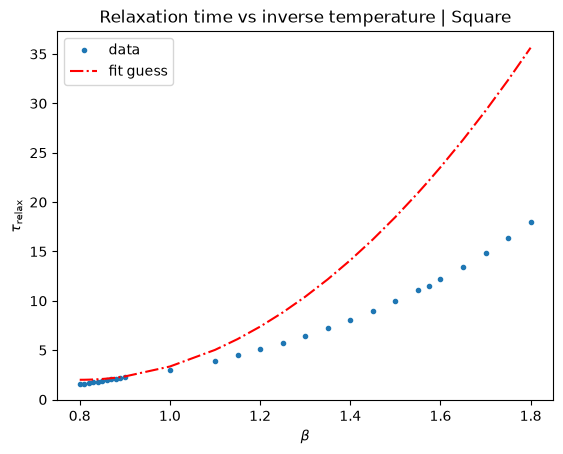

In [69]:
# ===== Data filtering =====
# Select beta range
beta_min_parabola = 0.8

print(f"Fitting parabolic scaling for beta >= {beta_min_parabola}")

# Filter nans for the plot
mask = (
    (beta_list_short >= beta_min_parabola)
    & (~np.isnan(tau_list_short))
)

beta_list_short_filter = beta_list_short[mask]
tau_list_short_filter = tau_list_short[mask]

# ===== Plot =====
# Data.
plt.plot(
    beta_list_short_filter, 
    np.log(tau_list_short_filter), 
    '.',
    label='data'
)

# Fit guess.
J_guess, beta_q_guess, tau_q_log_guess = 5.8, 0.8, 2
t_fit_guess = J_guess**2 * np.power(beta_list_short_filter - beta_q_guess, 2) + tau_q_log_guess

plt.plot(
    beta_list_short_filter,
    t_fit_guess,
    label='fit guess',
    color='red',
    linestyle='-.'
)

plt.xlabel("$\\beta$")
plt.ylabel("$\\tau_{\\text{relax}}$")
plt.title("Relaxation time vs inverse temperature | Square")
plt.legend()

In [70]:
popt, pcov = np.polyfit(
    beta_list_short_filter, 
    np.log(tau_list_short_filter), 
    deg=2,
    cov=True
)
a, b, c = popt
var_a, var_b, var_c = np.diag(pcov)
cov_ab, cov_bc, cov_ac = pcov[0,1], pcov[1,2], pcov[0,2]

# --- J ---
J, std_J = get_parabolic_fit_J_and_stdJ(a, var_a)

# --- beta_q ---
beta_q, std_beta_q = get_parabolic_fit_beta_q_and_std_beta_q(
    a, b, var_a=var_a, var_b=var_b, cov_ab=cov_ab
)

# --- log(tau_q) and tau_q ---
log_tau_q, std_log_tau_q  = get_parabolic_fit_log_tau_q_and_std_log_tau_q(
    a, b, c,
    var_a=var_a, var_b=var_b, var_c=var_c,
    cov_ab=cov_ab, cov_bc=cov_bc, cov_ac=cov_ac
)
tau_q, std_tau_q = get_parabolic_fit_tau_q_and_std_tau_q(
    log_tau_q, std_log_tau_q
)

print(f"Found fit params: {popt}")
print(f"w/ uncertanties:\n{pcov}")
print("\nparam\t | estimate ± sigma | (% error)")
print("-" * 50)

print(f"J\t | {J:.2f} ± {std_J:.2f} | ({std_J/J:.1%})")
print(f"beta_q\t | {beta_q:.3f} ± {std_beta_q:.3f} | ({std_beta_q/beta_q:.1%})")
print(f"log(tau_q) | {log_tau_q:.2f} ± {std_log_tau_q:.2f} | ({std_log_tau_q/log_tau_q:.1%})")
print(f"tau_q \t| {tau_q:.2f} ± {std_tau_q:.2f} | ({std_tau_q/tau_q:.1%})")

Found fit params: [ 13.14037773 -18.26269238   7.94655663]
w/ uncertanties:
[[ 0.11459929 -0.28631     0.16557783]
 [-0.28631     0.72190607 -0.42161186]
 [ 0.16557783 -0.42161186  0.24953096]]

param	 | estimate ± sigma | (% error)
--------------------------------------------------
J	 | 3.62 ± 0.05 | (1.3%)
beta_q	 | 0.695 ± 0.015 | (2.1%)
log(tau_q) | 1.60 ± 0.08 | (5.1%)
tau_q 	| 4.96 ± 0.40 | (8.2%)


### Fit plot

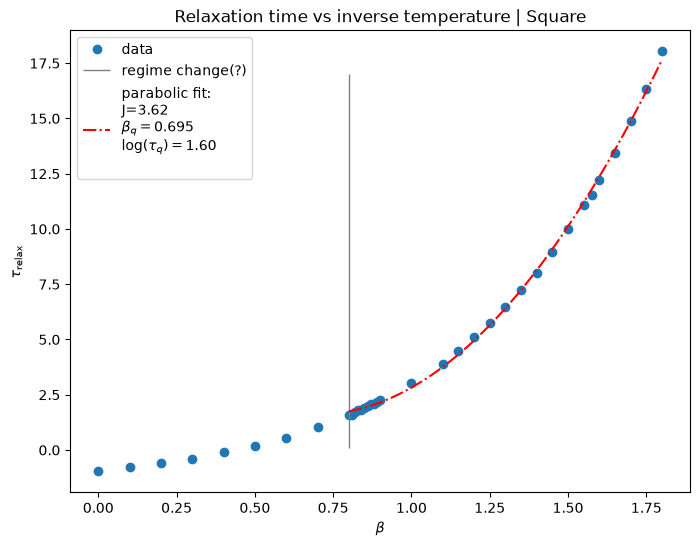

In [71]:
plt.figure(figsize=(8,6))

# ===== Data =====
plt.plot(
    beta_list_short, 
    np.log(tau_list_short), 
    'o', 
    label='data'
)

# ===== Delimiter =====
plt.vlines(
    0.8, 
    ymin=0.1,
    ymax=17,
    label='regime change(?)',
    color='gray',
    linewidth=1
)

# ===== Fit =====
b_fit = np.linspace(
    np.min(beta_list_short_filter),
    np.max(beta_list_short_filter),
    num=10000
)
t_fit = J**2 * np.power(b_fit - beta_q, 2) + log_tau_q

# ===== Plot =====
plt.plot(
    b_fit, 
    t_fit, 
    label=(
        f'parabolic fit:\nJ={J:.2f}\n'
        f'$\\beta_q={beta_q:.3f}$\n'
        f'$\\log(\\tau_q)={log_tau_q:.2f}$\n'
    ), 
    color='red', 
    linestyle='-.'
)

plt.xlabel("$\\beta$")
plt.ylabel("$\\tau_{\\text{relax}}$")
plt.title("Relaxation time vs inverse temperature | Square")
plt.legend()

### Save fit results

In [72]:
# Save results
filepath_save_fit = f"{outdirpath_data}/square_tau_fit.dat"

header_save_tau_fit = (
    "Square lattice - Fit result for relaxation "
    "time vs inverse temperature beta (high-beta regime).\n"
    "Function used: tau_q * exp(J**2(beta - beta_q))\n"
    "J | std_J | beta_q | std_beta_q | tau_q | std_tau_q" 
)

np.savetxt(
    fname=filepath_save_fit,
    X=[[J, std_J], [beta_q, std_beta_q], [tau_q, std_tau_q]],
    header=header_save_tau_fit
)

# Legacy

## Legacy alpha "manual" fitting

### beta = 1.40

In [73]:
# # ===== Fit-data =====
# # Select beta.
# beta_fit = 1.40
# beta_idx = beta_dict_long[beta_fit]

# print(f"Fit at beta = {beta_list_long[beta_idx]:1.2f}")

# # Select time range and fit-data.
# time_start_idx = 0
# time_stop_idx = 110

# time_list_fit14 = np.array(time_mat_long[beta_idx][time_start_idx:time_stop_idx])
# overlap_list_fit14 = np.array(overlap_mat_long[beta_idx][time_start_idx:time_stop_idx])

# # Fit guess
# p0 = [1, 10**4, .5]
# t = np.linspace(np.min(time_list_fit14), np.max(time_list_fit14), num=10000)
# fit_guess = stretched_exp(t, A=p0[0], t0=p0[1], alpha=p0[2])

# # ===== Plots =====
# nrows, ncols = 1, 2

# fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))

# # Plot 0 - Full interval.
# axs[0].plot(time_mat_long[beta_idx], overlap_mat_long[beta_idx], label=f'$\\beta$ = {beta_fit:2f}')

# axs[0].vlines(time_list_fit14[0], ymin=10**-4, ymax=1., color='green', linestyles='-.')
# axs[0].vlines(time_list_fit14[-1], ymin=10**-4, ymax=1., color='red', linestyles='-.')

# axs[0].set_xscale("log")
# axs[0].set_yscale("log")

# axs[0].set_xlabel("time / tau (log)")
# axs[0].set_ylabel("$\\log Q(t)$")

# # Plot 1 - Filtered data.
# axs[1].plot(time_list_fit14, overlap_list_fit14, label=f'$\\beta$ = {beta_fit:2f}')
# axs[1].plot(t, fit_guess, label=f'fit guess', linestyle='-.')

# axs[1].set_xscale("log")
# axs[1].set_yscale("log")

# axs[1].set_xlabel("time / tau (log)")
# axs[1].set_ylabel("$\\log Q(t)$")

# fig.suptitle(f"Fit for $\\beta$ = {beta_fit:1.2f}")

In [74]:
# popt, pcov = op.curve_fit(
#     f=log_stretched_exp,
#     xdata=time_list_fit14,
#     ydata=np.log(overlap_list_fit14),
#     p0=p0,
#     bounds=(
#         [0, 0, 0],
#         [np.inf, np.inf, np.inf]
#     )
# )
# A14, t014, alpha14 = popt


# print(f"Found fit params: {popt}")
# print(f"A = {A14:.1f}, t0 = {t014:.0e}, alpha = {alpha14:.3f}")

In [75]:
# fit_t = np.linspace(np.min(time_list_fit14), np.max(time_list_fit14), num=10000)
# fit_curve = log_stretched_exp(t, A=A14, t0=t014, alpha=alpha14)

# plt.plot(time_list_fit14, np.log(overlap_list_fit14), label='data')
# plt.plot(
#     fit_t, fit_curve, 
#     label=f'fit:\n$A$={A14:.1f}\n$t_0$={t014:.0f}\n$\\alpha$={alpha14:.2f}', 
#     linestyle='-.', 
#     color='red'
# )

# plt.xscale("log")

# plt.xlabel("time (log)")
# plt.ylabel("$\\log Q(t)$")
# plt.title(f"Stretched exponent fit | $\\beta$ = {beta_fit:1.2f} | Square")
# plt.legend()

### beta = 1.45

In [76]:
# # ===== Fit-data =====
# # Select beta.
# beta_fit = 1.45
# beta_idx = beta_dict_long[beta_fit]

# print(f"Fit at beta = {beta_list_long[beta_idx]:1.2f}")

# # Select time range and fit-data.
# time_start_idx = 0
# time_stop_idx = 110

# time_list_fit145 = np.array(time_mat_long[beta_idx][time_start_idx:time_stop_idx])
# overlap_list_fit145 = np.array(overlap_mat_long[beta_idx][time_start_idx:time_stop_idx])

# # Fit guess
# p0 = [1, 10**4, .5]
# t = np.linspace(np.min(time_list_fit145), np.max(time_list_fit145), num=10000)
# fit_guess = stretched_exp(t, A=p0[0], t0=p0[1], alpha=p0[2])

# # ===== Plots =====
# nrows, ncols = 1, 2

# fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))

# # Plot 0 - Full interval.
# axs[0].plot(time_mat_long[beta_idx], overlap_mat_long[beta_idx], label=f'$\\beta$ = {beta_fit:2f}')

# axs[0].vlines(time_list_fit145[0], ymin=10**-4, ymax=1., color='green', linestyles='-.')
# axs[0].vlines(time_list_fit145[-1], ymin=10**-4, ymax=1., color='red', linestyles='-.')

# axs[0].set_xscale("log")
# axs[0].set_yscale("log")

# axs[0].set_xlabel("time / tau (log)")
# axs[0].set_ylabel("$\\log Q(t)$")

# # Plot 1 - Filtered data.
# axs[1].plot(time_list_fit145, overlap_list_fit145, label=f'$\\beta$ = {beta_fit:2f}')
# axs[1].plot(t, fit_guess, label=f'fit guess', linestyle='-.')

# axs[1].set_xscale("log")
# axs[1].set_yscale("log")

# axs[1].set_xlabel("time / tau (log)")
# axs[1].set_ylabel("$\\log Q(t)$")

# fig.suptitle(f"Fit for $\\beta$ = {beta_fit:1.2f}")

In [77]:
# popt, pcov = op.curve_fit(
#     f=log_stretched_exp,
#     xdata=time_list_fit145,
#     ydata=np.log(overlap_list_fit145),
#     p0=p0,
#     bounds=(
#         [0, 0, 0],
#         [np.inf, np.inf, np.inf]
#     )
# )
# A145, t0145, alpha145 = popt


# print(f"Found fit params: {popt}")
# print(f"A = {A145:.1f}, t0 = {t0145:.0e}, alpha = {alpha145:.3f}")

In [78]:
# fit_t = np.linspace(np.min(time_list_fit145), np.max(time_list_fit145), num=10000)
# fit_curve = log_stretched_exp(t, A=A145, t0=t0145, alpha=alpha145)

# plt.plot(time_list_fit145, np.log(overlap_list_fit145), label='data')
# plt.plot(
#     fit_t, fit_curve, 
#     label=f'fit:\n$A$={A145:.1f}\n$t_0$={t0145:.0e}\n$\\alpha$={alpha145:.2f}', 
#     linestyle='-.', 
#     color='red'
# )

# plt.xscale("log")

# plt.xlabel("time (log)")
# plt.ylabel("$\\log Q(t)$")
# plt.title(f"Stretched exponent fit | $\\beta$ = {beta_fit:1.2f} | Square")
# plt.legend()

### beta = 1.50

In [79]:
# # ===== Fit-data =====
# # Select beta.
# beta_fit = 1.50
# beta_idx = beta_dict_long[beta_fit]

# print(f"Fit at beta = {beta_list_long[beta_idx]:1.2f}")

# # Select time range and fit-data.
# time_start_idx = 0
# time_stop_idx = 130

# time_list_fit15 = np.array(time_mat_long[beta_idx][time_start_idx:time_stop_idx])
# overlap_list_fit15 = np.array(overlap_mat_long[beta_idx][time_start_idx:time_stop_idx])

# # Fit guess
# p0 = [1, 10**5, .4]
# t = np.linspace(np.min(time_list_fit15), np.max(time_list_fit15), num=10000)
# fit_guess = stretched_exp(t, A=p0[0], t0=p0[1], alpha=p0[2])

# # ===== Plots =====
# nrows, ncols = 1, 2

# fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))

# # Plot 0 - Full interval.
# axs[0].plot(time_mat_long[beta_idx], overlap_mat_long[beta_idx], label=f'$\\beta$ = {beta_fit:2f}')

# axs[0].vlines(time_list_fit15[0], ymin=10**-4, ymax=1., color='green', linestyles='-.')
# axs[0].vlines(time_list_fit15[-1], ymin=10**-4, ymax=1., color='red', linestyles='-.')

# axs[0].set_xscale("log")
# axs[0].set_yscale("log")

# axs[0].set_xlabel("time / tau (log)")
# axs[0].set_ylabel("$\\log Q(t)$")

# # Plot 1 - Filtered data.
# axs[1].plot(time_list_fit15, overlap_list_fit15, label=f'$\\beta$ = {beta_fit:2f}')
# axs[1].plot(t, fit_guess, label=f'fit guess', linestyle='-.')

# axs[1].set_xscale("log")
# axs[1].set_yscale("log")

# axs[1].set_xlabel("time / tau (log)")
# axs[1].set_ylabel("$\\log Q(t)$")

# fig.suptitle(f"Fit for $\\beta$ = {beta_fit:1.2f}")

In [80]:
# popt, pcov = op.curve_fit(
#     f=log_stretched_exp,
#     xdata=time_list_fit15,
#     ydata=np.log(overlap_list_fit15),
#     p0=p0,
#     bounds=(
#         [0, 0, 0],
#         [np.inf, np.inf, np.inf]
#     )
# )
# A15, t015, alpha15 = popt

# print(f"Found fit params: {popt}")
# print(f"A = {A15:.1f}, t0 = {t015:.0e}, alpha = {alpha15:.3f}")

In [81]:
# fit_t = np.linspace(np.min(time_list_fit15), np.max(time_list_fit15), num=10000)
# fit_curve = log_stretched_exp(t, A=A15, t0=t015, alpha=alpha15)

# plt.plot(time_list_fit15, np.log(overlap_list_fit15), label='data')
# plt.plot(
#     fit_t, fit_curve, 
#     label=f'fit:\n$A$={A15:.1f}\n$t_0$={t015:.0e}\n$\\alpha$={alpha15:.2f}', 
#     linestyle='-.', 
#     color='red'
# )

# plt.xscale("log")

# plt.xlabel("time (log)")
# plt.ylabel("$\\log Q(t)$")
# plt.title(f"Stretched exponent fit | $\\beta$ = {beta_fit:1.2f} | Square 2d")
# plt.legend()

### beta = 1.55

In [82]:
# # ===== Fit-data =====
# # Select beta.
# beta_fit = 1.55
# beta_idx = beta_dict_long[beta_fit]

# print(f"Fit at beta = {beta_list_long[beta_idx]:1.2f}")

# # Select time range and fit-data.
# time_start_idx = 0
# time_stop_idx = 140

# time_list_fit155 = np.array(time_mat_long[beta_idx][time_start_idx:time_stop_idx])
# overlap_list_fit155 = np.array(overlap_mat_long[beta_idx][time_start_idx:time_stop_idx])

# # Fit guess
# p0 = [1, 10**6, .4]
# t = np.linspace(np.min(time_list_fit155), np.max(time_list_fit155), num=10000)
# fit_guess = stretched_exp(t, A=p0[0], t0=p0[1], alpha=p0[2])

# # ===== Plots =====
# nrows, ncols = 1, 2

# fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))

# # Plot 0 - Full interval.
# axs[0].plot(time_mat_long[beta_idx], overlap_mat_long[beta_idx], label=f'$\\beta$ = {beta_fit:2f}')

# axs[0].vlines(time_list_fit155[0], ymin=10**-4, ymax=1., color='green', linestyles='-.')
# axs[0].vlines(time_list_fit155[-1], ymin=10**-4, ymax=1., color='red', linestyles='-.')

# axs[0].set_xscale("log")
# axs[0].set_yscale("log")

# axs[0].set_xlabel("time / tau (log)")
# axs[0].set_ylabel("$\\log Q(t)$")

# # Plot 1 - Filtered data.
# axs[1].plot(time_list_fit155, overlap_list_fit155, label=f'$\\beta$ = {beta_fit:2f}')
# axs[1].plot(t, fit_guess, label=f'fit guess', linestyle='-.')

# axs[1].set_xscale("log")
# axs[1].set_yscale("log")

# axs[1].set_xlabel("time / tau (log)")
# axs[1].set_ylabel("$\\log Q(t)$")

# fig.suptitle(f"Fit for $\\beta$ = {beta_fit:1.2f}")

In [83]:
# popt, pcov = op.curve_fit(
#     f=log_stretched_exp,
#     xdata=time_list_fit155,
#     ydata=np.log(overlap_list_fit155),
#     p0=p0,
#     bounds=(
#         [0, 0, 0],
#         [np.inf, np.inf, np.inf]
#     )
# )
# A155, t0155, alpha155 = popt

# print(f"Found fit params: {popt}")
# print(f"A = {A155:.1f}, t0 = {t0155:.0e}, alpha = {alpha155:.3f}")

In [84]:
# fit_t = np.linspace(np.min(time_list_fit155), np.max(time_list_fit155), num=10000)
# fit_curve = log_stretched_exp(t, A=A155, t0=t0155, alpha=alpha155)

# plt.plot(time_list_fit155, np.log(overlap_list_fit155), label='data')
# plt.plot(
#     fit_t, fit_curve, 
#     label=f'fit:\n$A$={A155:.1f}\n$t_0$={t0155:.0e}\n$\\alpha$={alpha155:.2f}', 
#     linestyle='-.', 
#     color='red'
# )

# plt.xscale("log")

# plt.xlabel("time (log)")
# plt.ylabel("$\\log Q(t)$")
# plt.title(f"Stretched exponent fit | $\\beta$ = {beta_fit:1.2f} | Square 2d")
# plt.legend()

### beta = 1.60

In [85]:
# # ===== Fit-data =====
# # Select beta.
# beta_fit = 1.60
# beta_idx = beta_dict_long[beta_fit]

# print(f"Fit at beta = {beta_list_long[beta_idx]:1.2f}")

# # Select time range and fit-data.
# time_start_idx = 0
# time_stop_idx = 150

# time_list_fit16 = np.array(time_mat_long[beta_idx][time_start_idx:time_stop_idx])
# overlap_list_fit16 = np.array(overlap_mat_long[beta_idx][time_start_idx:time_stop_idx])

# # Fit guess
# p0 = [1, 10**6, .5]
# t = np.linspace(np.min(time_list_fit16), np.max(time_list_fit16), num=10000)
# fit_guess = stretched_exp(t, A=p0[0], t0=p0[1], alpha=p0[2])

# # ===== Plots =====
# nrows, ncols = 1, 2

# fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))

# # Plot 0 - Full interval.
# axs[0].plot(time_mat_long[beta_idx], overlap_mat_long[beta_idx], label=f'$\\beta$ = {beta_fit:2f}')

# axs[0].vlines(time_list_fit16[0], ymin=10**-4, ymax=1., color='green', linestyles='-.')
# axs[0].vlines(time_list_fit16[-1], ymin=10**-4, ymax=1., color='red', linestyles='-.')

# axs[0].set_xscale("log")
# axs[0].set_yscale("log")

# axs[0].set_xlabel("time / tau (log)")
# axs[0].set_ylabel("$\\log Q(t)$")

# # Plot 1 - Filtered data.
# axs[1].plot(time_list_fit16, overlap_list_fit16, label=f'$\\beta$ = {beta_fit:2f}')
# axs[1].plot(t, fit_guess, label=f'fit guess', linestyle='-.')

# axs[1].set_xscale("log")
# axs[1].set_yscale("log")

# axs[1].set_xlabel("time / tau (log)")
# axs[1].set_ylabel("$\\log Q(t)$")

# fig.suptitle(f"Fit for $\\beta$ = {beta_fit:1.2f}")

In [86]:
# popt, pcov = op.curve_fit(
#     f=log_stretched_exp,
#     xdata=time_list_fit16,
#     ydata=np.log(overlap_list_fit16),
#     p0=p0,
#     bounds=(
#         [0, 0, 0],
#         [np.inf, np.inf, np.inf]
#     )
# )
# A16, t016, alpha16 = popt

# print(f"Found fit params: {popt}")
# print(f"A = {A16:.1f}, t0 = {t016:.0e}, alpha = {alpha16:.3f}")

In [87]:
# fit_t = np.linspace(np.min(time_list_fit16), np.max(time_list_fit16), num=10000)
# fit_curve = log_stretched_exp(t, A=A16, t0=t016, alpha=alpha16)

# plt.plot(time_list_fit16, np.log(overlap_list_fit16), label='data')
# plt.plot(
#     fit_t, fit_curve, 
#     label=f'fit:\n$A$={A16:.1f}\n$t_0$={t016:.0e}\n$\\alpha$={alpha16:.2f}', 
#     linestyle='-.', 
#     color='red'
# )

# plt.xscale("log")

# plt.xlabel("time (log)")
# plt.ylabel("$\\log Q(t)$")
# plt.title(f"Stretched exponent fit | $\\beta$ = {beta_fit:1.2f} | Square")
# plt.legend()

### beta = 1.65

In [88]:
# # ===== Fit-data =====
# # Select beta.
# beta_fit = 1.65
# beta_idx = beta_dict_long[beta_fit]

# print(f"Fit at beta = {beta_list_long[beta_idx]:1.2f}")

# # Select time range and fit-data.
# time_start_idx = 0
# time_stop_idx = 150

# time_list_fit165 = np.array(time_mat_long[beta_idx][time_start_idx:time_stop_idx])
# overlap_list_fit165 = np.array(overlap_mat_long[beta_idx][time_start_idx:time_stop_idx])

# # Fit guess
# p0 = [1, 10**6, .5]
# t = np.linspace(np.min(time_list_fit165), np.max(time_list_fit165), num=10000)
# fit_guess = stretched_exp(t, A=p0[0], t0=p0[1], alpha=p0[2])

# # ===== Plots =====
# nrows, ncols = 1, 2

# fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))

# # Plot 0 - Full interval.
# axs[0].plot(time_mat_long[beta_idx], overlap_mat_long[beta_idx], label=f'$\\beta$ = {beta_fit:2f}')

# axs[0].vlines(time_list_fit165[0], ymin=10**-4, ymax=1., color='green', linestyles='-.')
# axs[0].vlines(time_list_fit165[-1], ymin=10**-4, ymax=1., color='red', linestyles='-.')

# axs[0].set_xscale("log")
# axs[0].set_yscale("log")

# axs[0].set_xlabel("time / tau (log)")
# axs[0].set_ylabel("$\\log Q(t)$")

# # Plot 1 - Filtered data.
# axs[1].plot(time_list_fit165, overlap_list_fit165, label=f'$\\beta$ = {beta_fit:2f}')
# axs[1].plot(t, fit_guess, label=f'fit guess', linestyle='-.')

# axs[1].set_xscale("log")
# axs[1].set_yscale("log")

# axs[1].set_xlabel("time / tau (log)")
# axs[1].set_ylabel("$\\log Q(t)$")

# fig.suptitle(f"Fit for $\\beta$ = {beta_fit:1.2f}")

In [89]:
# popt, pcov = op.curve_fit(
#     f=log_stretched_exp,
#     xdata=time_list_fit165,
#     ydata=np.log(overlap_list_fit165),
#     p0=p0,
#     bounds=(
#         [0, 0, 0],
#         [np.inf, np.inf, np.inf]
#     )
# )
# A165, t0165, alpha165 = popt

# print(f"Found fit params: {popt}")
# print(f"A = {A165:.1f}, t0 = {t0165:.0e}, alpha = {alpha165:.3f}")

In [90]:
# fit_t = np.linspace(np.min(time_list_fit165), np.max(time_list_fit165), num=10000)
# fit_curve = log_stretched_exp(t, A=A165, t0=t0165, alpha=alpha16)

# plt.plot(time_list_fit165, np.log(overlap_list_fit165), label='data')
# plt.plot(
#     fit_t, fit_curve, 
#     label=f'fit:\n$A$={A165:.1f}\n$t_0$={t0165:.0e}\n$\\alpha$={alpha165:.2f}', 
#     linestyle='-.', 
#     color='red'
# )

# plt.xscale("log")

# plt.xlabel("time (log)")
# plt.ylabel("$\\log Q(t)$")
# plt.title(f"Stretched exponent fit | $\\beta$ = {beta_fit:1.2f} | Square")
# plt.legend()

### beta = 1.70

In [91]:
# # ===== Fit-data =====
# # Select beta.
# beta_fit = 1.70
# beta_idx = beta_dict_long[beta_fit]

# print(f"Fit at beta = {beta_list_long[beta_idx]:1.2f}")

# # Select time range and fit-data.
# time_start_idx = 0
# time_stop_idx = 150

# time_list_fit17 = np.array(time_mat_long[beta_idx][time_start_idx:time_stop_idx])
# overlap_list_fit17 = np.array(overlap_mat_long[beta_idx][time_start_idx:time_stop_idx])

# # Fit guess
# p0 = [1, 10**7, .45]
# t = np.linspace(np.min(time_list_fit17), np.max(time_list_fit17), num=10000)
# fit_guess = stretched_exp(t, A=p0[0], t0=p0[1], alpha=p0[2])

# # ===== Plots =====
# nrows, ncols = 1, 2

# fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))

# # Plot 0 - Full interval.
# axs[0].plot(time_mat_long[beta_idx], overlap_mat_long[beta_idx], label=f'$\\beta$ = {beta_fit:1f}')

# axs[0].vlines(time_list_fit17[0], ymin=10**-4, ymax=1., color='green', linestyles='-.')
# axs[0].vlines(time_list_fit17[-1], ymin=10**-4, ymax=1., color='red', linestyles='-.')

# axs[0].set_xscale("log")
# axs[0].set_yscale("log")

# axs[0].set_xlabel("time / tau (log)")
# axs[0].set_ylabel("$\\log Q(t)$")

# # Plot 1 - Filtered data.
# axs[1].plot(time_list_fit17, overlap_list_fit17, label=f'$\\beta$ = {beta_fit:1f}')
# axs[1].plot(t, fit_guess, label=f'fit guess', linestyle='-.')

# axs[1].set_xscale("log")
# axs[1].set_yscale("log")

# axs[1].set_xlabel("time / tau (log)")
# axs[1].set_ylabel("$\\log Q(t)$")

# fig.suptitle(f"Fit for $\\beta$ = {beta_fit:1.2f}")

In [92]:
# popt, pcov = op.curve_fit(
#     f=log_stretched_exp,
#     xdata=time_list_fit17,
#     ydata=np.log(overlap_list_fit17),
#     p0=p0,
#     bounds=(
#         [0, 0, 0],
#         [np.inf, np.inf, np.inf]
#     )
# )
# A17, t017, alpha17 = popt

# print(f"Found fit params: {popt}")
# print(f"A = {A17:.1f}, t0 = {t017:.0e}, alpha = {alpha17:.3f}")

In [93]:
# fit_t = np.linspace(np.min(time_list_fit17), np.max(time_list_fit17), num=10000)
# fit_curve = log_stretched_exp(t, A=A17, t0=t017, alpha=alpha17)

# plt.plot(time_list_fit17, np.log(overlap_list_fit17), label='data')
# plt.plot(
#     fit_t, fit_curve, 
#     label=f'fit:\n$A$={A17:.1f}\n$t_0$={t017:.0f}\n$\\alpha$={alpha17:.2f}', 
#     linestyle='-.', 
#     color='red'
# )

# plt.xscale("log")

# plt.xlabel("time (log)")
# plt.ylabel("$\\log Q(t)$")
# plt.title(f"Stretched exponent fit | $\\beta$ = {beta_fit:1.2f} | Square 2d")
# plt.legend()

## Fit results

In [94]:
# beta_fit_list = np.array([
#     1.40, 1.45, 1.50, 1.55, 1.60, 1.65, 1.70
# ])

# A_fit_list = np.array([
#     A14, A145, A15, A155, A16, A165, A17
# ])
# t0_fit_list = np.array([
#     t014, t0145, t015, t0155, t016, t0165, t017
# ])
# alpha_fit_list = np.array([
#     alpha14, alpha145, alpha15, alpha155, alpha16, alpha165, alpha17
# ])

In [95]:
# nrows, ncols = 1, 3

# fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))

# # ===== A plot =====
# plot_idx = 0

# axs[plot_idx].plot(beta_fit_list, A_fit_list, 'o')
# axs[plot_idx].set_xlabel("$\\beta$")
# axs[plot_idx].set_ylabel("$A$")

# # ===== t0 plot =====
# plot_idx = 1

# axs[plot_idx].plot(beta_fit_list, t0_fit_list, 'o')
# axs[plot_idx].set_yscale("log")
# axs[plot_idx].set_xlabel("$\\beta$")
# axs[plot_idx].set_ylabel("$t_0$")

# # ===== alpha plot =====
# plot_idx = 2

# axs[plot_idx].plot(beta_fit_list, alpha_fit_list, 'o')
# axs[plot_idx].set_xlabel("$\\beta$")
# axs[plot_idx].set_ylabel("$\\alpha$")

### Save fit results

In [96]:
# # Save results
# filepath_save_fit = f"{outdirpath_data}/square_stretched_exp_fit.dat"

# header_save_stretched_fit = (
#     "Square lattice - Fit result for overlap vs time.\n"
#     "beta | A | t0 | alpha"
# )

# np.savetxt(
#     fname=filepath_save_fit,
#     X=np.transpose(
#         [beta_fit_list, A_fit_list, t0_fit_list, alpha_fit_list]
#     ),
#     header=header_save_stretched_fit
# )